<a href="https://colab.research.google.com/github/PrathamLaddha/Lipophilicity_Prediction_NNs/blob/main/GAT_DMPNN_OPERA_stdized_test_fixed.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ── Cell 1: Install dependencies ──────────────────────────────────────────────
try:
    from torch_geometric.datasets import MoleculeNet
    from torch_geometric.loader import DataLoader
    from torch_geometric.nn import MessagePassing, global_add_pool
except ImportError:
    print("Installing torch_geometric...")
    import subprocess
    subprocess.run(["pip", "install", "torch_geometric"], check=True)

try:
    from rdkit import Chem
except ImportError:
    print("Installing rdkit...")
    import subprocess
    subprocess.run(["pip", "install", "rdkit"], check=True)

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Installing torch_geometric...
Installing rdkit...
PyTorch version: 2.11.0+cu128
CUDA available: True
Using device: cuda


In [2]:
# ── Cell 2: Featurizer (fixed — no duplicate structural features) ──────────────
from torch_geometric.transforms import BaseTransform
from torch_geometric.datasets import MoleculeNet
from torch_geometric.loader import DataLoader
from rdkit import Chem
from rdkit.Chem import Descriptors
import torch

class MolecularFeaturizer(BaseTransform):

    def forward(self, data):
        mol = Chem.MolFromSmiles(data.smiles)
        if mol is None:
            return data

        # Global molecular descriptors (same value broadcast to every atom for context)
        tpsa    = Descriptors.TPSA(mol) / 500.0
        f_csp3  = Descriptors.FractionCSP3(mol)

        new_x = []
        for i, atom in enumerate(mol.GetAtoms()):
            # Baseline features already in data.x (9 dims from PyG MoleculeNet)
            baseline = data.x[i].tolist()

            # New, non-redundant features only
            formal_charge = float(atom.GetFormalCharge())

            # Final: 9 baseline + 3 new = 12 features
            atom_features = baseline + [formal_charge, tpsa, f_csp3]
            new_x.append(atom_features)

        data.x = torch.tensor(new_x, dtype=torch.float)
        return data

In [3]:
# ── Cell 3: Build dataset from OPERA only (Lipophilicity/MoleculeNet dataset removed) ─
# NOTE: The MoleculeNet "Lipophilicity" dataset has been dropped entirely — its
# targets do not correspond to LogP values, so mixing them with OPERA LogP data
# was corrupting the regression target. We now build the dataset purely from the
# OPERA experimental LogP SDF files.
import torch
import numpy as np
from rdkit import Chem
from torch_geometric.utils import from_smiles
from tqdm import tqdm
from collections import defaultdict

# 1. Read OPERA SDF files (train + test structure files)
print("Reading OPERA structure data files (.sdf)...")
suppl_train = Chem.SDMolSupplier('TR_LogP_10537.sdf')
suppl_val   = Chem.SDMolSupplier('TST_LogP_3513.sdf')
combined_sdf = list(suppl_train) + list(suppl_val)

# 2. Extract OPERA molecules & store by InChIKey (dedupe repeated entries)
molecules_dict = defaultdict(list)

for mol in tqdm(combined_sdf, desc="Parsing OPERA"):
    if mol is None:
        continue
    try:
        smiles = Chem.MolToSmiles(mol)
        logp_val = float(mol.GetProp('LogP'))
        inchikey = Chem.MolToInchiKey(mol)

        molecules_dict[inchikey].append({
            'smiles': smiles,
            'logp': logp_val,
            'source': 'OPERA'
        })
    except Exception:
        continue

# 3. Resolve duplicates & Featurize
print("\nDeduplicating and constructing PyG graph objects...")
featurizer = MolecularFeaturizer()
dataset = []

duplicates_count = 0
conflicts_skipped = 0

for inchikey, entries in tqdm(molecules_dict.items(), desc="Featurizing"):
    if len(entries) > 1:
        duplicates_count += 1
        logp_values = [e['logp'] for e in entries]

        # Skip if experimental values deviate too drastically across duplicate entries (> 1.0 log unit)
        if np.ptp(logp_values) > 1.0:
            conflicts_skipped += 1
            continue

        # Take mean LogP across duplicates
        final_logp = float(np.mean(logp_values))
    else:
        final_logp = entries[0]['logp']

    canonical_smiles = entries[0]['smiles']

    try:
        data = from_smiles(canonical_smiles)
        if data is None or data.x is None:
            continue

        data.y = torch.tensor([[final_logp]], dtype=torch.float)
        data.smiles = canonical_smiles
        data = featurizer(data)
        dataset.append(data)
    except Exception:
        continue

print(f"\n--- Deduplication Summary ---")
print(f"Unique InChIKeys Identified: {len(molecules_dict)}")
print(f"Duplicate Compound Groups:   {duplicates_count}")
print(f"High-Variance Conflicts Dropped: {conflicts_skipped}")
print(f"Final Master Dataset Size:   {len(dataset)}")


Reading OPERA structure data files (.sdf)...


[19:25:48] Explicit valence for atom # 1 N, 4, is greater than permitted
[19:25:48] ERROR: Could not sanitize molecule ending on line 146438
[19:25:48] ERROR: Explicit valence for atom # 1 N, 4, is greater than permitted
[19:25:48] Explicit valence for atom # 1 N, 4, is greater than permitted
[19:25:48] ERROR: Could not sanitize molecule ending on line 233170
[19:25:48] ERROR: Explicit valence for atom # 1 N, 4, is greater than permitted
[19:25:49] Explicit valence for atom # 8 N, 4, is greater than permitted
[19:25:49] ERROR: Could not sanitize molecule ending on line 400722
[19:25:49] ERROR: Explicit valence for atom # 8 N, 4, is greater than permitted
[19:25:49] Explicit valence for atom # 5 N, 4, is greater than permitted
[19:25:49] ERROR: Could not sanitize molecule ending on line 406654
[19:25:49] ERROR: Explicit valence for atom # 5 N, 4, is greater than permitted
[19:25:49] Explicit valence for atom # 9 N, 4, is greater than permitted
[19:25:49] ERROR: Could not sanitize molecu


Deduplicating and constructing PyG graph objects...


Featurizing: 100%|██████████| 14031/14031 [00:16<00:00, 837.37it/s]


--- Deduplication Summary ---
Unique InChIKeys Identified: 14031
Duplicate Compound Groups:   8
High-Variance Conflicts Dropped: 7
Final Master Dataset Size:   14024


In [4]:
# ── Cell 4: Bemis-Murcko Scaffold Split (OPERA-only) & DataLoader Initialization ───
# Simplified for the OPERA-only dataset: every Data object already carries its own
# `smiles` attribute (set during featurization above), so the old MoleculeNet /
# lipo_dataset fallback branches are no longer needed.
import torch
from torch_geometric.loader import DataLoader
from collections import defaultdict
from rdkit import Chem
from rdkit.Chem.Scaffolds import MurckoScaffold

# Set random seed for reproducibility
torch.manual_seed(42)
n = len(dataset)

print("Calculating molecular frameworks for Bemis-Murcko Scaffold Split...")
scaffolds = defaultdict(list)

# 1. Group every molecule index by its structural framework scaffold
for idx, data in enumerate(dataset):
    try:
        mol = Chem.MolFromSmiles(data.smiles)
        scaffold = MurckoScaffold.MurckoScaffoldSmiles(mol=mol, includeChirality=False)
    except Exception:
        scaffold = ""  # Fallback bucket for unparsable structures

    scaffolds[scaffold].append(idx)

# 2. Sort structural families from largest to smallest to distribute fairly
scaffold_sets = sorted(list(scaffolds.values()), key=len, reverse=True)

train_idx, val_idx, test_idx = [], [], []
n_train = int(0.8 * n)   # 80%
n_val   = int(0.1 * n)   # 10%

# 3. Distribute grouped structures systematically into splits
for scaffold_set in scaffold_sets:
    if len(train_idx) + len(scaffold_set) <= n_train:
        train_idx.extend(scaffold_set)
    elif len(train_idx) + len(val_idx) + len(scaffold_set) <= n_train + n_val:
        val_idx.extend(scaffold_set)
    else:
        test_idx.extend(scaffold_set)

# 4. Wrap slices in DataLoaders
train_loader = DataLoader([dataset[i] for i in train_idx], batch_size=32, shuffle=True)
val_loader   = DataLoader([dataset[i] for i in val_idx],   batch_size=32, shuffle=False)
test_loader  = DataLoader([dataset[i] for i in test_idx],  batch_size=32, shuffle=False)

print(f"\nScaffold Split Complete:")
print(f"Train: {len(train_idx)} ({len(train_idx)/n:.1%}) | "
      f"Val: {len(val_idx)} ({len(val_idx)/n:.1%}) | "
      f"Test: {len(test_idx)} ({len(test_idx)/n:.1%})")


Calculating molecular frameworks for Bemis-Murcko Scaffold Split...

Scaffold Split Complete:
Train: 11219 (80.0%) | Val: 1402 (10.0%) | Test: 1403 (10.0%)


In [5]:
# ── Cell 5: Standardize target values (zero mean / unit variance) ────────────
# Statistics are computed from the TRAIN split only, to avoid leaking
# information about the val/test distributions into training.
#
# Toggle STANDARDIZE_TARGETS to False to reproduce the original (raw LogP-unit)
# behaviour and compare accuracy with/without standardization.
import numpy as np
import torch

STANDARDIZE_TARGETS = True

train_y_vals = np.array([dataset[i].y.item() for i in train_idx])

y_mean = float(np.mean(train_y_vals))
y_std  = float(np.std(train_y_vals))

print(f"Training Targets -> Mean: {y_mean:.4f} | Std: {y_std:.4f}")

if STANDARDIZE_TARGETS:
    # train_loader/val_loader/test_loader were built from references to the same
    # `dataset` Data objects, so mutating dataset[i].y here updates the targets
    # the loaders will actually see during training/eval.
    for i in range(len(dataset)):
        raw_y = dataset[i].y.item()
        dataset[i].y = torch.tensor([[(raw_y - y_mean) / y_std]], dtype=torch.float)
    print("Targets standardized to zero mean / unit variance for training.")
else:
    print("Targets left in raw LogP units (no standardization applied).")


Training Targets -> Mean: 2.0313 | Std: 1.8313
Targets standardized to zero mean / unit variance for training.


In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import MessagePassing

class DMPNNConv(MessagePassing):
    def __init__(self, hidden_dim):
        super().__init__(aggr='add', flow='source_to_target')
        self.lin = nn.Linear(hidden_dim, hidden_dim)
        self.bn  = nn.BatchNorm1d(hidden_dim)

    def forward(self, x, edge_index, edge_attr):
        # Propagate: message() combines atom + bond features
        out = self.propagate(edge_index, x=x, edge_attr=edge_attr)
        return F.relu(self.bn(out))

    def message(self, x_j, edge_attr):
        # x_j: source atom features | edge_attr: bond features
        return self.lin(x_j + edge_attr)

In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATv2Conv, global_add_pool

class MolecularGraphEncoder(nn.Module):
    def __init__(self, num_node_features, num_edge_features, hidden_dim):
        super().__init__()

        # Embed raw features into hidden space
        self.node_emb = nn.Linear(num_node_features, hidden_dim)
        self.edge_emb = nn.Linear(num_edge_features, hidden_dim)

        # FIX: DMPNN layer is now wired in as the first message passing step
        self.dmpnn = DMPNNConv(hidden_dim)
        self.ln0   = nn.LayerNorm(hidden_dim)

        # GAT layers for attention-based aggregation
        self.conv1 = GATv2Conv(hidden_dim, hidden_dim // 2, heads=2, edge_dim=hidden_dim, dropout=0.1)
        self.ln1   = nn.LayerNorm(hidden_dim)

        self.conv2 = GATv2Conv(hidden_dim, hidden_dim // 2, heads=2, edge_dim=hidden_dim, dropout=0.1)
        self.ln2   = nn.LayerNorm(hidden_dim)

        # Virtual node MLP: lets global graph state inform local node updates
        self.virtual_node_mlp = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )

    def forward(self, data):
        x         = data.x.float()
        edge_index= data.edge_index
        edge_attr = data.edge_attr
        batch     = data.batch

        # Handle 1D edge attributes (scalar bond types)
        if edge_attr.dim() == 1:
            edge_attr = edge_attr.unsqueeze(-1)
        edge_attr = edge_attr.float()

        # 1. Embed into hidden space
        x = F.relu(self.node_emb(x))
        edge_attr = F.relu(self.edge_emb(edge_attr))

        # 2. DMPNN: edge-aware directed message passing
        x = self.ln0(x + self.dmpnn(x, edge_index, edge_attr))  # residual

        # 3. GATv2 layer 1
        x = self.ln1(self.conv1(x, edge_index, edge_attr))
        x = F.relu(x)

        # 4. GATv2 layer 2
        x = self.ln2(self.conv2(x, edge_index, edge_attr))
        x = F.relu(x)

        # 5. Global pooling + virtual node refinement
        graph_emb = global_add_pool(x, batch)
        graph_emb = graph_emb + self.virtual_node_mlp(graph_emb)

        return x, graph_emb

In [8]:
import torch.nn as nn
import torch.nn.functional as F

class LipophilicityDMPNN(nn.Module):
    def __init__(self, encoder, hidden_dim):
        super().__init__()
        self.encoder  = encoder
        self.fc1      = nn.Linear(hidden_dim, hidden_dim // 2)
        self.dropout  = nn.Dropout(0.2)
        self.fc2      = nn.Linear(hidden_dim // 2, 1)

    def forward(self, data):
        _, graph_emb = self.encoder(data)
        x = F.relu(self.fc1(graph_emb))
        x = self.dropout(x)
        return self.fc2(x)


# Initialise model from scratch (no broken pre-trained weights)
input_dim = dataset[0].num_node_features    # 12
edge_dim  = dataset[0].num_edge_features
HIDDEN    = 128

encoder = MolecularGraphEncoder(
    num_node_features=input_dim,
    num_edge_features=edge_dim,
    hidden_dim=HIDDEN
)
model = LipophilicityDMPNN(encoder, hidden_dim=HIDDEN).to(device)

# FIX: Single unified learning rate — no pre-trained weights to protect
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

# FIX: Scheduler now driven off validation loss (wired in training loop below)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=10)
criterion = nn.MSELoss()

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model ready | input_dim={input_dim} | edge_dim={edge_dim} | params={total_params:,}")


Model ready | input_dim=12 | edge_dim=3 | params=160,385


In [9]:
# ── Cell 7: Train / Validate helpers ──────────────────────────────────────────

def train_epoch():
    model.train()
    total_loss = 0
    for data in train_loader:
        data = data.to(device)
        optimizer.zero_grad()
        pred = model(data).view(-1)
        loss = criterion(pred, data.y.view(-1))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(train_loader)


@torch.no_grad()
def eval_epoch(loader):
    model.eval()
    total_loss = 0
    for data in loader:
        data = data.to(device)
        pred = model(data).view(-1)
        total_loss += criterion(pred, data.y.view(-1)).item()
    return total_loss / len(loader)

In [10]:
NUM_EPOCHS    = 150
PATIENCE      = 40     # stop if val loss doesn't improve for 40 epochs
best_val_loss = float('inf')
patience_ctr  = 0

train_losses, val_losses = [], []

print("Starting training...\n")
for epoch in range(1, NUM_EPOCHS + 1):
    train_loss = train_epoch()
    val_loss   = eval_epoch(val_loader)

    # Scheduler steps on VALIDATION loss
    scheduler.step(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if epoch % 10 == 0:
        print(f"Epoch {epoch:03d} | Train MSE: {train_loss:.4f} | Val MSE: {val_loss:.4f}")

    # Early stopping — save best checkpoint (based on validation loss only)
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_ctr  = 0
        torch.save(model.state_dict(), "best_model.pt")
    else:
        patience_ctr += 1
        if patience_ctr >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch} (best val MSE: {best_val_loss:.4f})")
            break

print("\nTraining complete.")

# Test set is intentionally NOT touched during training/early-stopping/scheduling —
# it is only evaluated once, after training is fully complete (see the Test set
# evaluation cell below), to keep it an unbiased estimate of generalization.


Starting training...

Epoch 010 | Train MSE: 0.1511 | Val MSE: 0.1918
Epoch 020 | Train MSE: 0.1072 | Val MSE: 0.1635
Epoch 030 | Train MSE: 0.0839 | Val MSE: 0.1740
Epoch 040 | Train MSE: 0.0633 | Val MSE: 0.1555
Epoch 050 | Train MSE: 0.0594 | Val MSE: 0.1261
Epoch 060 | Train MSE: 0.0511 | Val MSE: 0.1397
Epoch 070 | Train MSE: 0.0458 | Val MSE: 0.1358
Epoch 080 | Train MSE: 0.0434 | Val MSE: 0.1336

Early stopping at epoch 88 (best val MSE: 0.1242)

Training complete.


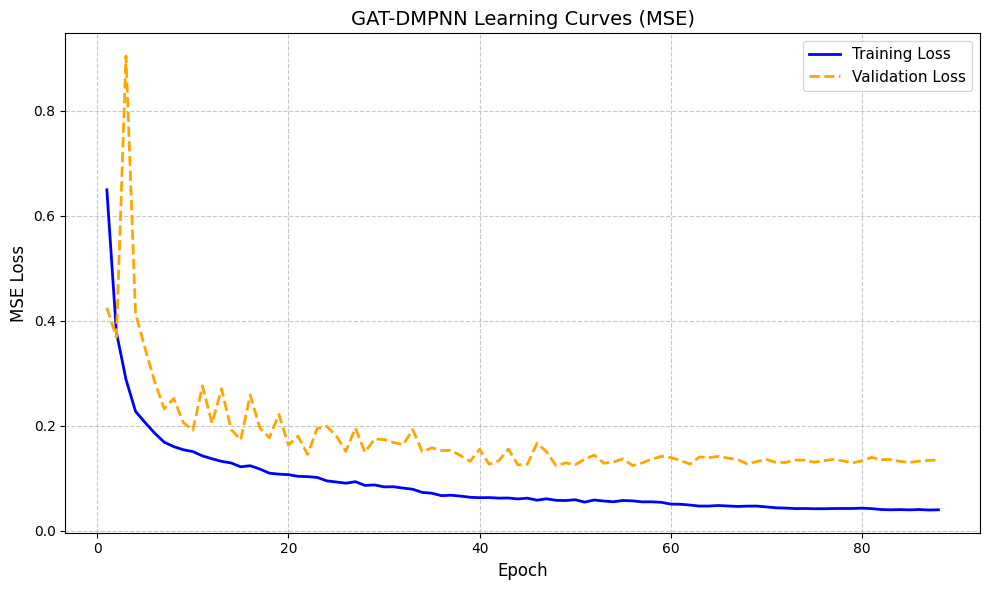

Best validation MSE: 0.1242


In [11]:
# ── Cell 9: Loss curves (train + val) ─────────────────────────────────────────
import matplotlib.pyplot as plt

epochs_ran = len(train_losses)

plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs_ran + 1), train_losses, label='Training Loss',   color='blue',   linewidth=2)
plt.plot(range(1, epochs_ran + 1), val_losses,   label='Validation Loss', color='orange', linewidth=2, linestyle='--')
plt.title('GAT-DMPNN Learning Curves (MSE)', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('MSE Loss', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('loss_curve_fixed.png', dpi=150)
plt.show()
print(f"Best validation MSE: {best_val_loss:.4f}")
# Note: test-set loss is deliberately not tracked per-epoch or plotted here —
# it's evaluated exactly once, after training, in the Test set evaluation cell.


In [12]:
# ── Cell 10: Test set evaluation (run ONLY after training is complete) ────────
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Load best checkpoint (selected using validation loss only)
model.load_state_dict(torch.load("best_model.pt", map_location=device))
model.eval()

# Test loss (MSE), computed once, here — not during training
test_loss = eval_epoch(test_loader)

all_preds, all_targets = [], []
with torch.no_grad():
    for data in test_loader:
        data = data.to(device)
        pred = model(data).view(-1).cpu().numpy()
        tgt  = data.y.view(-1).cpu().numpy()
        all_preds.append(pred)
        all_targets.append(tgt)

all_preds   = np.concatenate(all_preds)
all_targets = np.concatenate(all_targets)

# Undo standardization so metrics/plots are reported in real LogP units
if STANDARDIZE_TARGETS:
    all_preds   = all_preds * y_std + y_mean
    all_targets = all_targets * y_std + y_mean

mae  = mean_absolute_error(all_targets, all_preds)
rmse = np.sqrt(mean_squared_error(all_targets, all_preds))
r2   = r2_score(all_targets, all_preds)

print("\n--- TEST SET RESULTS ---")
print(f"Test MSE (standardized-target loss, matches training-loop scale): {test_loss:.4f}")
print(f"MAE:  {mae:.4f} (Average error in LogP units)")
print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f} (Correlation)")



--- TEST SET RESULTS ---
Test MSE (standardized-target loss, matches training-loop scale): 0.1412
MAE:  0.4838 (Average error in LogP units)
RMSE: 0.6880
R²:   0.8530 (Correlation)


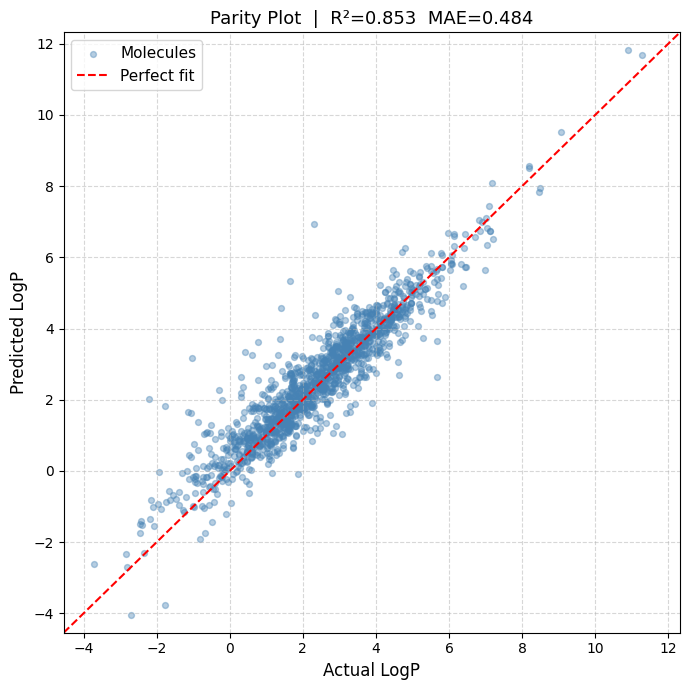

In [13]:
# ── Cell 11: Parity plot (predicted vs actual) ─────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(all_targets, all_preds, alpha=0.4, s=18, color='steelblue', label='Molecules')

lo = min(all_targets.min(), all_preds.min()) - 0.5
hi = max(all_targets.max(), all_preds.max()) + 0.5
ax.plot([lo, hi], [lo, hi], 'r--', linewidth=1.5, label='Perfect fit')

ax.set_xlabel('Actual LogP',    fontsize=12)
ax.set_ylabel('Predicted LogP', fontsize=12)
ax.set_title(f'Parity Plot  |  R²={r2:.3f}  MAE={mae:.3f}', fontsize=13)
ax.legend(fontsize=11)
ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('parity_plot.png', dpi=150)
plt.show()